In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.unsupervised.classic.SHE import SHETorchConfidence
from confidence.unsupervised.classic.dice import DICEConfidence
from confidence.unsupervised.classic.lof import LOFTorchConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
#get name of notebook this kernel runs
notebook_name = os.path.basename(globals()['__session__'])  # Get the name without extension
#remove the extension
notebook_name = os.path.splitext(notebook_name)[0]

In [5]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset, NoPILEMNIST

dataset = 'emnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'emnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILEMNIST(experiment_files_path_data)
    n_classes = len(dataset_train.classes)
    dataset_val_test = NoPILEMNIST(experiment_files_path_data,train=False)
    #split into validation and test set
    dataset_val, dataset_test_pre = torch.utils.data.random_split(dataset_val_test,[0.5,0.5])


transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17


#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence, create_parameter_sampler, create_sampler

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device="cpu",reflect=True,use_individual_param_correction=False)



sampler = create_sampler(transform_seq)

dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=batch_size)

transform_seq.to(device)


In [6]:
dataset_test[0]

(tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.000

In [7]:
dataset_train_transformed = AffineTransformDataset(dataset_train,sampler,return_transformation=False,batch_size=batch_size)


In [8]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [9]:
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)

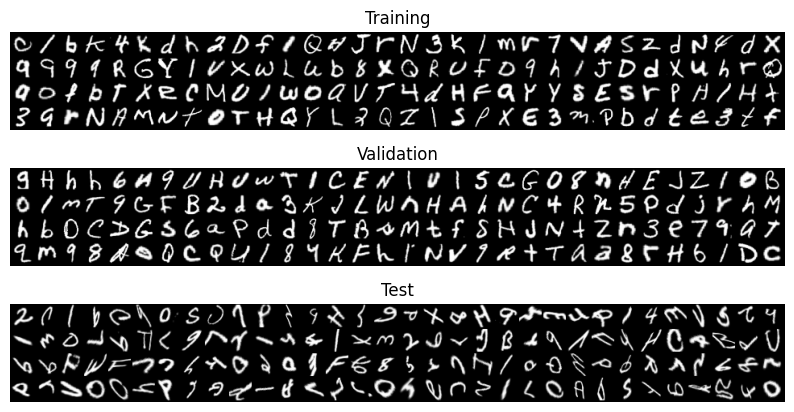

In [10]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [11]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\emnist_metric.pth


In [12]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [13]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=47, bias=True)
)

In [14]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.8741489361702127.


In [15]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.21393617021276595.


In [16]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric3.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(128),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(256),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),  # Output: 256x7x7
    nn.BatchNorm2d(256),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x4x4
    nn.Flatten(),
    nn.Linear(256 * 3 * 3, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model2, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader_transformed, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model2.state_dict(), model_path)
    print(f"Model saved to {model_path}")


with torch.no_grad():
    model2.eval().cuda()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

model2= None
torch.cuda.empty_cache()

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\emnist_metric3.pth
Mean accuracy on the transformed test set: 0.6888297872340425.


In [17]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model2, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader_transformed, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model2.state_dict(), model_path)
    print(f"Model saved to {model_path}")


with torch.no_grad():
    model2.eval().cuda()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')


model2= None
torch.cuda.empty_cache()

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\emnist_metric2.pth
Mean accuracy on the transformed test set: 0.6263829787234042.


In [18]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=47, bias=True)
)

In [19]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True).eval()

In [20]:
filter_correct = True  # Set to False to include all samples

embeddings = []
images = []
classes = []
logits = []

for data, target in train_loader:
    data_cuda = data.cuda()
    emb_batch, logit_batch = dual_ouput_model(data_cuda)
    pred_batch = logit_batch.argmax(dim=-1).cpu().numpy()
    target_np = target.numpy()

    if filter_correct:
        mask = pred_batch == target_np
        emb_np = emb_batch.detach().cpu().numpy()[mask]
        logit_np = logit_batch.detach().cpu().numpy()[mask]
        img_np = data.numpy()[mask]
        class_np = target_np[mask]
    else:
        emb_np = emb_batch.detach().cpu().numpy()
        logit_np = logit_batch.detach().cpu().numpy()
        img_np = data.numpy()
        class_np = target_np

    embeddings.append(emb_np)
    logits.append(logit_np)
    images.append(img_np)
    classes.append(class_np)

embeddings = np.vstack(embeddings)
logits     = np.vstack(logits)
images     = np.vstack(images)
classes    = np.hstack(classes)

# randomly sample 5000 entries
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    logits_sampled     = logits[indices]
    images_sampled     = images[indices]
    classes_sampled    = classes[indices]
else:
    embeddings_sampled = embeddings
    logits_sampled     = logits
    images_sampled     = images
    classes_sampled    = classes

In [21]:

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence

In [22]:
import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
di_no_grad = search.shgo.SHGO(selection_method="topk", local_max_steps=0)

In [23]:
dual_ouput_model_input = ModelInputWrapper(model,'0',flatten=False).eval()

In [24]:
def evaluate_conf(model, di, problem, test_loader, max_batch_override=None):
    if max_batch_override is not None:
        problem.max_batch_size = max_batch_override
    with torch.no_grad():
        test_acc_sim = 0
        counter = 0
        for data, target in tqdm.tqdm(test_loader):
            data, target = data.cuda(), target.cuda()
            with torch.enable_grad():
                res = di.optimize(problem, data.cuda(), y=target.cuda())
                res = list(res)
            torch.cuda.empty_cache()
            res[0] = res[0].detach()  # Detach the result to avoid gradients
            res[1] = res[1].detach()  # Detach the result to avoid gradients
            # Apply the transformation and get predictions
            x_transformed2 = problem.transform(data.cuda(), res[0])
            logits = model(x_transformed2)
            output = logits.argmax(dim=-1)
            test_acc_sim += output.eq(target).sum().cpu().detach().item()
            counter += output.shape[0]

    test_acc_sim /= counter
    return test_acc_sim


import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence

conf_mod_nn_pytorch = SinglePassConfidence(model, EnergyConfidence())
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di, problem_nn_pytorch, test_loader)

100%|██████████| 74/74 [00:14<00:00,  4.99it/s]


0.5876595744680851

In [25]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.01)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

evaluate_conf(model, di, problem_nn_pytorch, test_loader)

100%|██████████| 74/74 [00:16<00:00,  4.37it/s]


0.6298936170212766

In [26]:
from confidence.unsupervised.classic.nn_pytorch import _compute_cosine_distance

def compute_mixed_distance(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Weighted sum of Euclidean and cosine distances (0.5 each).
    """
    euclid = torch.cdist(x, y, p=2)
    cos = _compute_cosine_distance(x, y)
    return cos +0.0001 * euclid

In [27]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric=compute_mixed_distance,k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.01)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

evaluate_conf(model, di, problem_nn_pytorch, test_loader)

100%|██████████| 74/74 [00:17<00:00,  4.15it/s]


0.6248936170212765

C:\Users\Lindner\AppData\Local\Temp\ipykernel_4896\961874154.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  transformed_images = transform_rotate_only.transform(torch.repeat_interleave(torch.tensor(random_image).float(), sample_count, dim=0), params)
C:\Users\Lindner\AppData\Local\Temp\ipykernel_4896\961874154.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image_grid = torchvision.utils.make_grid(torch.tensor(transformed_images).float(), nrow=5, normalize=True, scale_each=True)


Text(0.5, 1.0, "Transformed Images with Predicted Classes: ['Y', 'Y', 'J', '5', 'h', 'h', 'S', 'g', 'Y']")

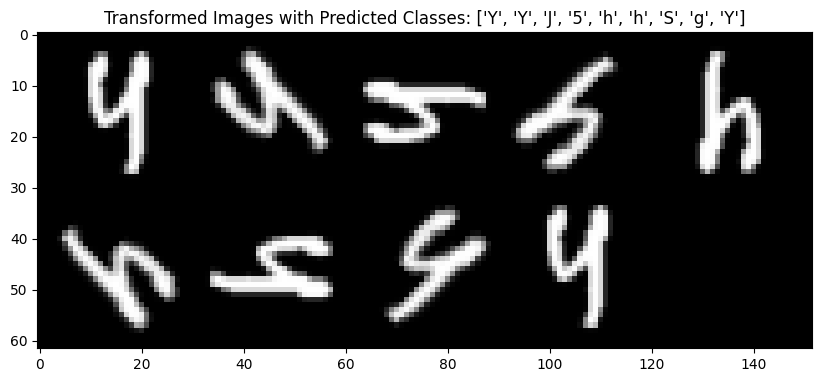

In [28]:
#choose an image

random_image =next(iter(val_loader))[0][2].reshape(1, 1, 28, 28)

#rotate it smoothly
transform_rotate_only = TransformSequence([AffineTransformation2D.ROTATION.value], [(-torch.pi, torch.pi)], neighbour_hood_size=0.25, application_method=grid_resample, device="cuda", reflect=True, use_individual_param_correction=False)
sample_count = 9
params = torch.linspace(-torch.pi, torch.pi, sample_count).reshape(-1, 1)

transformed_images = transform_rotate_only.transform(torch.repeat_interleave(torch.tensor(random_image).float(), sample_count, dim=0), params)

#classify the transformed images
with torch.no_grad():
    dual_ouput_model.eval()
    logits = dual_ouput_model(transformed_images.cuda())[1]
    classes = logits.argmax(dim=-1).cpu().numpy()
    #translate to string classes
    classes = [dataset_train.classes[c] for c in classes]

image_grid = torchvision.utils.make_grid(torch.tensor(transformed_images).float(), nrow=5, normalize=True, scale_each=True)
# Plot the transformed images with their predicted classes
plt.figure(figsize=(10, 5))
plt.imshow(image_grid.permute(1, 2, 0).cpu())
plt.title(f"Transformed Images with Predicted Classes: {classes}")

Text(0.5, 1.0, "Rectified Images with Predicted Classes: ['h', 'h', 'h', 'h', 'h', 'h', 'h', 'h', 'h']")

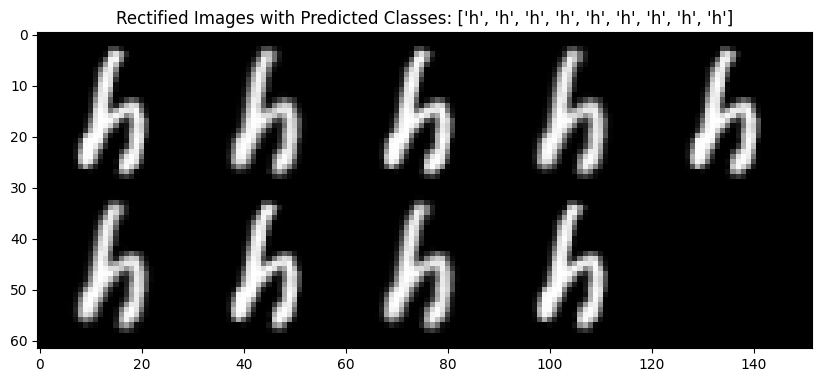

In [29]:
#now try to rectify the image using confidence
problem_rotate_only = TransformationProblem(conf_mod_nn_pytorch.cuda(), transform_rotate_only, consolidate_method="consolidate_simple")



with torch.no_grad():
    dual_ouput_model.eval()
    res = di.optimize(problem_rotate_only, transformed_images.cuda())
    untransformed_images = problem_rotate_only.transform(transformed_images.cuda(), res[0])

    logits = dual_ouput_model(untransformed_images.cuda())[1]
    classes = logits.argmax(dim=-1).cpu().numpy()
    #translate to string classes
    classes = [dataset_train.classes[c] for c in classes]

image_grid = torchvision.utils.make_grid(untransformed_images, nrow=5, normalize=True, scale_each=True)
# Plot the transformed images with their predicted classes
plt.figure(figsize=(10, 5))
plt.imshow(image_grid.permute(1, 2, 0).cpu())
plt.title(f"Rectified Images with Predicted Classes: {classes}")


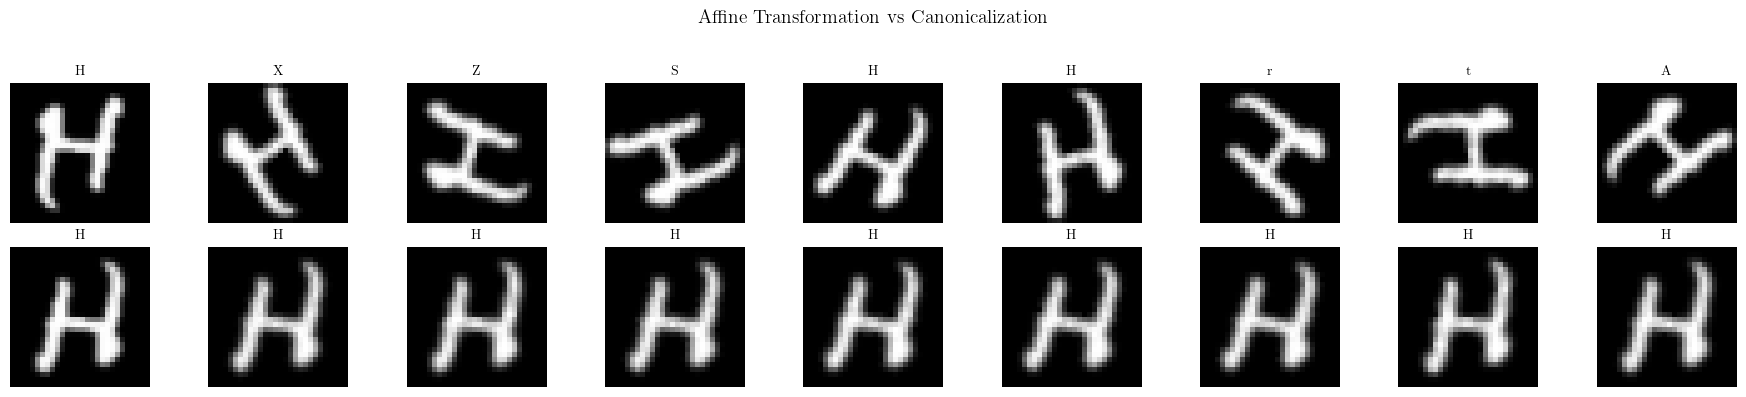

In [43]:
random_image = next(iter(val_loader))[0][8].reshape(1, 1, 28, 28)
transform_rotate_only = TransformSequence(
    [AffineTransformation2D.ROTATION.value],
    [(-torch.pi, torch.pi)],
    neighbour_hood_size=0.25,
    application_method=grid_resample,
    device="cuda",
    reflect=True,
    use_individual_param_correction=False
)
sample_count = 9
params = torch.linspace(-torch.pi, torch.pi - 2 * torch.pi / sample_count,
                        sample_count).reshape(-1, 1)
rotated_images = transform_rotate_only.transform(
    torch.repeat_interleave(random_image.float(), sample_count, dim=0),
    params
)

# classify rotated images
with torch.no_grad():
    dual_ouput_model.eval()
    logits_rot = dual_ouput_model(rotated_images.cuda())[1]
    preds_rot = logits_rot.argmax(dim=-1).cpu().numpy()
classes_rot = [dataset_train.classes[c] for c in preds_rot]

# canonicalize rotated images
problem_rotate_only = TransformationProblem(
    conf_mod_nn_pytorch.cuda(),
    transform_rotate_only,
    consolidate_method="consolidate_simple"
)
with torch.no_grad():
    res = di.optimize(problem_rotate_only, rotated_images.cuda())
    canon_images = problem_rotate_only.transform(rotated_images.cuda(), res[0])
    logits_canon = dual_ouput_model(canon_images)[1]
    preds_canon = logits_canon.argmax(dim=-1).cpu().numpy()
classes_canon = [dataset_train.classes[c] for c in preds_canon]

# plot side-by-side rows: rotated vs canonicalized
fig, axs = plt.subplots(2, sample_count, figsize=(2 * sample_count, 4), squeeze=False)
for i in range(sample_count):
    axs[0, i].imshow(rotated_images[i].cpu().squeeze(), cmap='gray')
    axs[0, i].set_title(classes_rot[i], fontsize=10)
    axs[0, i].axis('off')
    axs[1, i].imshow(canon_images[i].cpu().squeeze(), cmap='gray')
    axs[1, i].set_title(classes_canon[i], fontsize=10)
    axs[1, i].axis('off')

# annotate rows and figure
axs[0, 0].set_ylabel('Rotated', fontsize=12)
axs[1, 0].set_ylabel('Canonicalized', fontsize=12)
fig.suptitle('Affine Transformation vs Canonicalization', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

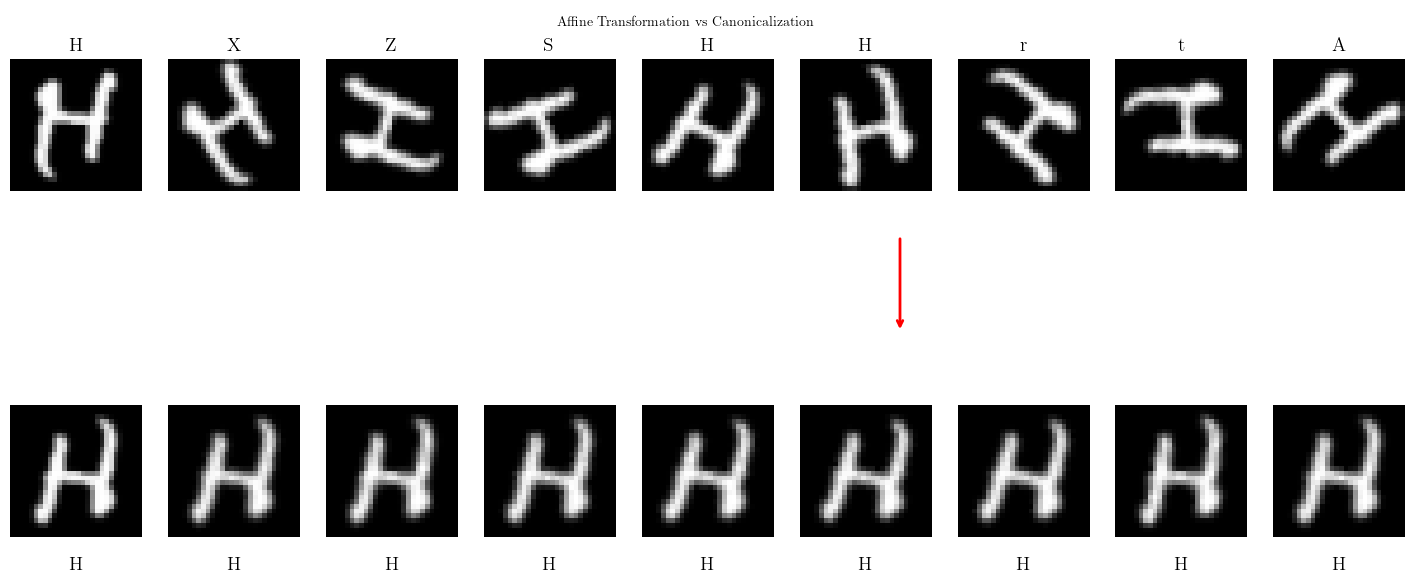

In [46]:
# increase gap, plot two rows, add bottom labels and central arrow
fig, axs = plt.subplots(2, sample_count, figsize=(2 * sample_count, 6), squeeze=False)

for i in range(sample_count):
    # top row: rotated images
    axs[0, i].imshow(rotated_images[i].cpu().squeeze(), cmap='gray')
    axs[0, i].set_title(classes_rot[i], fontsize=14)
    axs[0, i].axis('off')

    # bottom row: canonicalized images
    axs[1, i].imshow(canon_images[i].cpu().squeeze(), cmap='gray')
    axs[1, i].axis('off')
    # text label below each canonicalized image
    axs[1, i].text(
        0.5, -0.15, classes_canon[i],
        ha='center', va='top',
        transform=axs[1, i].transAxes,
        fontsize=14
    )

# row labels
axs[0, 0].set_ylabel('\normalsize{Rotated}', fontsize=16, labelpad=15)
axs[1, 0].set_ylabel('\normalsize{Canonicalized}', fontsize=16, labelpad=15)

# leave space for labels and arrow
fig.subplots_adjust(hspace=1.2, top=0.92, bottom=0.08)

arrow_ax = fig.add_subplot(111, frameon=False)
arrow_ax.annotate(
    '',
    xy=(0.5, 0.42),        # arrow tail (below midpoint)
    xytext=(0.5, 0.58),    # arrow head (above midpoint)
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle='->', color='red', lw=2)
)
arrow_ax.axis('off')

fig.suptitle(r'\normalsize{Affine Transformation vs Canonicalization}', fontsize=18)
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",  # or xelatex, lualatex
    "font.family": "lmodern",  # Latin Modern font
    "text.usetex": True,
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{lmodern}"


})

plt.show()

SinglePassConfidence(
  (model): ModelInputWrapper(
    (model): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=3136, out_features=128, bias=True)
      (10): Dropout(p=0.5, inplace=False)
      (11): GELU(approximate='none')
      (12): Linear(in_features=128, out_features=47, bias=True)
    )
  )
  (confidence): PredictedSplitConfidence(
    (confidence_trust): PerClassKNNConfi

In [64]:
#caclulate the confidence of the rotated and canonicalized images
conf = problem_rotate_only.confidence_module(transformed_images.cuda())[0]
print(f"Confidence of rotated images: {conf}")

Confidence of rotated images: tensor([1.0653, 0.9085, 0.9503, 0.8948, 1.0757, 0.8729, 0.9086, 0.9031, 1.0653],
       device='cuda:0', grad_fn=<AddBackward0>)


In [56]:
import os
import csv
import torch
from torchvision.utils import save_image

# --- Assume these variables are defined in your environment ---
# Example data (replace with your actual data)
sample_count = transformed_images.shape[0]  # Number of samples
rotated_images = transformed_images  # Assuming these are the rotated images
canon_images = untransformed_images  # Assuming these are the canonicalized images
classes_rot = logits_rot.argmax(dim=-1).cpu().numpy()  # Classes for rotated images
classes_rot = [dataset_train.classes[c] for c in classes_rot]  # Convert to string classes
classes_canon = logits_canon.argmax(dim=-1).cpu().numpy()  # Classes for canonicalized images
classes_canon = [dataset_train.classes[c] for c in classes_canon]  # Convert to string classes
# -----------------------------------------------------------

# --- Configuration ---
output_dir = "fig/background/canon_example"
os.makedirs(output_dir, exist_ok=True)
label_file_path = os.path.join(output_dir, "labels.csv")

# --- Save Images and Labels ---
with open(label_file_path, 'w', newline='') as csvfile:
    label_writer = csv.writer(csvfile)
    # Write header
    label_writer.writerow(['index', 'rotated_label', 'canonical_label'])

    for i in range(sample_count):
        # Save the rotated image
        save_image(rotated_images[i], os.path.join(output_dir, f"rotated_{i}.png"))

        # Save the canonicalized image
        save_image(canon_images[i], os.path.join(output_dir, f"canonical_{i}.png"))

        # Write the corresponding labels to the CSV file
        label_writer.writerow([i, classes_rot[i], classes_canon[i]])

print(f"✅ Saved {sample_count} image pairs and labels to the '{output_dir}' directory.")

✅ Saved 9 image pairs and labels to the 'fig/background/canon_example' directory.


['Digit 3', 'Digit 8', 'Digit 9', 'Digit 1']

9

In [103]:
evaluate_conf(model, di, problem_rotate_only, test_loader)


100%|██████████| 74/74 [00:15<00:00,  4.63it/s]


0.6171276595744681